In [9]:
import pandas as pd
from pathlib import Path

REPORT_DIR = Path("../reports")
OUTPUT_DIR = Path("../dashboard")
OUTPUT_DIR.mkdir(exist_ok=True)

performance = pd.read_csv(
    REPORT_DIR / "monthly_performance_complete.csv"
)

channel = pd.read_csv(
    REPORT_DIR / "channel_performance.csv"
)

investment = pd.read_csv(
    REPORT_DIR / "investment_recommendation.csv"
)

actual_avg_mom = performance["mom_growth_pct"].dropna().mean()
actual_median_mom = performance["mom_growth_pct"].dropna().median()

complete_period_growth = (
    (performance.iloc[-1]["recovery"] -
     performance.iloc[0]["recovery"])
    / performance.iloc[0]["recovery"]
    * 100
)

actual_post_recovery = 722665699.69
counterfactual_recovery = 745746214.22

targeting_impact = (
    actual_post_recovery -
    counterfactual_recovery
)

overall_ptp_kept_rate = 49.646096

print("Final submission data loaded successfully.")
print(f"Average MoM: {actual_avg_mom:.2f}%")
print(f"Median MoM: {actual_median_mom:.2f}%")
print(f"Jan-Jul growth: {complete_period_growth:.2f}%")

Final submission data loaded successfully.
Average MoM: 0.29%
Median MoM: 0.30%
Jan-Jul growth: 0.01%


In [10]:
dq = pd.DataFrame({
    "Issue": [
        "Multiple dispositions per call",
        "RPC inflation from many-to-one join",
        "Partial August data",
        "December call-data spillover",
        "PTP/payment mismatch",
        "Cost data unavailable"
    ],
    "Impact": [
        "Call-level grain is not one-to-one",
        "Naive RPC can exceed 100%",
        "August cannot be used for normal MoM comparison",
        "December is not a valid recovery month",
        "Recorded KEPT status does not consistently align with nearby payment evidence",
        "Cost per ₹ recovered cannot be reliably calculated"
    ],
    "Treatment": [
        "Retain raw events; require call-level disposition rule",
        "Exclude unvalidated RPC from final decision",
        "Exclude August from MoM trend",
        "Exclude December from recovery trend",
        "Flag for business-rule validation",
        "State as data limitation"
    ]
})

display(dq)

,Issue,Impact,Treatment
0,Multiple dispositions per call,Call-level grain is not one-to-one,Retain raw events; require call-level disposit...
1,RPC inflation from many-to-one join,Naive RPC can exceed 100%,Exclude unvalidated RPC from final decision
2,Partial August data,August cannot be used for normal MoM comparison,Exclude August from MoM trend
3,December call-data spillover,December is not a valid recovery month,Exclude December from recovery trend
4,PTP/payment mismatch,Recorded KEPT status does not consistently ali...,Flag for business-rule validation
5,Cost data unavailable,Cost per ₹ recovered cannot be reliably calcul...,State as data limitation


In [11]:
import pandas as pd
from pathlib import Path
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.chart import LineChart, BarChart, Reference

REPORT_DIR = Path("../reports")
OUTPUT_DIR = Path("../dashboard")
OUTPUT_DIR.mkdir(exist_ok=True)

# Load existing results
performance = pd.read_csv(
    REPORT_DIR / "monthly_performance_complete.csv"
)

channel = pd.read_csv(
    REPORT_DIR / "channel_performance.csv"
)

# -----------------------------
# Key metrics
# -----------------------------

july = performance.iloc[-1]

reported = 11
avg_mom = performance["mom_growth_pct"].dropna().mean()

actual_post = 722665699.69
counterfactual = 745746214.22
targeting_impact = actual_post - counterfactual

ptp_kept = 49.646096

best_channel = channel.loc[
    channel["recovery_per_targeted_account"].idxmax()
]

# -----------------------------
# Workbook
# -----------------------------

wb = Workbook()
ws = wb.active
ws.title = "Executive Dashboard"

ws.sheet_view.showGridLines = False

# Title
ws.merge_cells("A1:H2")
ws["A1"] = "COLLECTIONS PERFORMANCE — EXECUTIVE DASHBOARD"
ws["A1"].font = Font(size=20, bold=True)
ws["A1"].alignment = Alignment(
    horizontal="center",
    vertical="center"
)

# KPI cards
kpis = [
    ("A4:B6", "JULY RECOVERY",
     f"₹{july['recovery']/1e7:.2f} Cr"),

    ("C4:D6", "JULY MoM",
     f"{july['mom_growth_pct']:.2f}%"),

    ("E4:F6", "REPORTED CLAIM",
     "11%"),

    ("G4:H6", "ACTUAL AVG MoM",
     f"{avg_mom:.2f}%"),

    ("A8:B10", "TARGETING IMPACT",
     f"₹{targeting_impact/1e7:.2f} Cr"),

    ("C8:D10", "PTP KEPT RATE",
     f"{ptp_kept:.2f}%"),

    ("E8:F10", "BEST CHANNEL",
     best_channel["recommended_channel"]),

    ("G8:H10", "BEST CHANNEL ₹/ACCOUNT",
     f"₹{best_channel['recovery_per_targeted_account']:,.0f}")
]

for cell_range, label, value in kpis:
    ws.merge_cells(cell_range)

    start = cell_range.split(":")[0]
    cell = ws[start]

    cell.value = f"{label}\n{value}"
    cell.font = Font(size=14, bold=True)
    cell.alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )

    cell.fill = PatternFill(
        fill_type="solid",
        fgColor="E8EEF7"
    )

# -----------------------------
# Recovery data
# -----------------------------

start_row = 13

ws[f"A{start_row}"] = "Month"
ws[f"B{start_row}"] = "Recovery"
ws[f"C{start_row}"] = "MoM Growth"

for i, row in performance.iterrows():
    r = start_row + i + 1

    ws[f"A{r}"] = row["month"]
    ws[f"B{r}"] = row["recovery"]
    ws[f"C{r}"] = row["mom_growth_pct"]

# Recovery chart
chart = LineChart()
chart.title = "Monthly Recovery"
chart.y_axis.title = "Recovery (₹)"
chart.x_axis.title = "Month"

data = Reference(
    ws,
    min_col=2,
    min_row=start_row,
    max_row=start_row + len(performance)
)

cats = Reference(
    ws,
    min_col=1,
    min_row=start_row + 1,
    max_row=start_row + len(performance)
)

chart.add_data(data, titles_from_data=True)
chart.set_categories(cats)
chart.height = 7
chart.width = 14

ws.add_chart(chart, "E13")

# -----------------------------
# MoM chart
# -----------------------------

mom_chart = LineChart()
mom_chart.title = "Observed MoM Recovery vs Reported 11%"
mom_chart.y_axis.title = "MoM Growth (%)"
mom_chart.x_axis.title = "Month"

mom_data = Reference(
    ws,
    min_col=3,
    min_row=start_row,
    max_row=start_row + len(performance)
)

mom_chart.add_data(
    mom_data,
    titles_from_data=True
)

mom_chart.set_categories(cats)
mom_chart.height = 7
mom_chart.width = 14

ws.add_chart(mom_chart, "E28")

# -----------------------------
# Channel table
# -----------------------------

channel_row = 43

ws[f"A{channel_row}"] = "Channel"
ws[f"B{channel_row}"] = "Recovery / Targeted Account"

for i, row in channel.iterrows():
    r = channel_row + i + 1

    ws[f"A{r}"] = row["recommended_channel"]
    ws[f"B{r}"] = row["recovery_per_targeted_account"]

# Channel chart
bar = BarChart()
bar.title = "Recovery per Targeted Account"
bar.y_axis.title = "₹"
bar.x_axis.title = "Channel"

bar_data = Reference(
    ws,
    min_col=2,
    min_row=channel_row,
    max_row=channel_row + len(channel)
)

bar_cats = Reference(
    ws,
    min_col=1,
    min_row=channel_row + 1,
    max_row=channel_row + len(channel)
)

bar.add_data(
    bar_data,
    titles_from_data=True
)

bar.set_categories(bar_cats)
bar.height = 7
bar.width = 14

ws.add_chart(bar, "E43")

# -----------------------------
# CEO takeaway
# -----------------------------

ws.merge_cells("A50:H54")

ws["A50"] = (
    "CEO TAKEAWAY\n"
    "The reported +11% MoM recovery improvement is not supported "
    "by the independently reconstructed January–July data. "
    f"Average observed MoM growth was {avg_mom:.2f}%. "
    "The simple targeting counterfactual estimates approximately "
    f"₹{abs(targeting_impact)/1e7:.2f} Cr lower recovery than the "
    "pre-change baseline. This is not causal proof. "
    "Current data does not support a reliable ₹10 Cr ROI estimate."
)

ws["A50"].alignment = Alignment(
    wrap_text=True,
    vertical="center"
)

ws["A50"].font = Font(
    size=12,
    bold=True
)

ws["A50"].fill = PatternFill(
    fill_type="solid",
    fgColor="FFF2CC"
)

# -----------------------------
# Formatting
# -----------------------------

for col in ["A", "B", "C", "D", "E", "F", "G", "H"]:
    ws.column_dimensions[col].width = 18

for row in range(1, 55):
    ws.row_dimensions[row].height = 22

# Save
output = OUTPUT_DIR / "executive_dashboard.xlsx"

wb.save(output)

print(f"Dashboard created: {output.resolve()}")

Dashboard created: C:\Users\ridhi\OneDrive\Desktop\collections-analysis\dashboard\executive_dashboard.xlsx


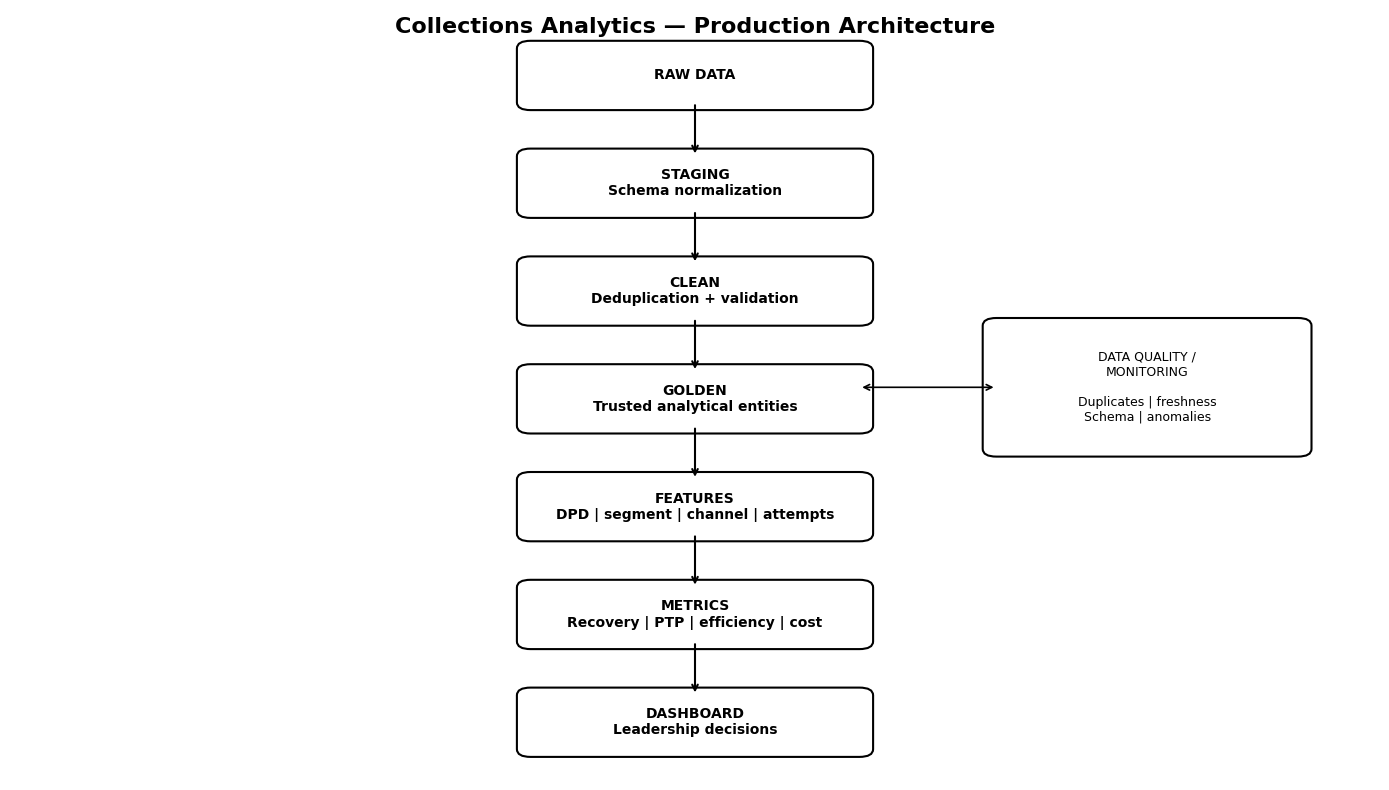

Created: C:\Users\ridhi\OneDrive\Desktop\collections-analysis\docs\architecture_diagram.png


In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

OUTPUT_DIR = Path("../docs")
OUTPUT_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

boxes = [
    ("RAW DATA", 0.38, 0.88, 0.24, 0.07),
    ("STAGING\nSchema normalization", 0.38, 0.74, 0.24, 0.07),
    ("CLEAN\nDeduplication + validation", 0.38, 0.60, 0.24, 0.07),
    ("GOLDEN\nTrusted analytical entities", 0.38, 0.46, 0.24, 0.07),
    ("FEATURES\nDPD | segment | channel | attempts", 0.38, 0.32, 0.24, 0.07),
    ("METRICS\nRecovery | PTP | efficiency | cost", 0.38, 0.18, 0.24, 0.07),
    ("DASHBOARD\nLeadership decisions", 0.38, 0.04, 0.24, 0.07),
]

for text, x, y, w, h in boxes:
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.01",
        linewidth=1.5,
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(
        x + w/2,
        y + h/2,
        text,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

for i in range(len(boxes) - 1):
    _, x, y, w, h = boxes[i]
    _, nx, ny, nw, nh = boxes[i + 1]

    ax.annotate(
        "",
        xy=(nx + nw/2, ny + nh),
        xytext=(x + w/2, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )

# Data quality / monitoring
dq_box = FancyBboxPatch(
    (0.72, 0.43), 0.22, 0.16,
    boxstyle="round,pad=0.01",
    linewidth=1.5,
    facecolor="white"
)
ax.add_patch(dq_box)

ax.text(
    0.83, 0.51,
    "DATA QUALITY /\nMONITORING\n\nDuplicates | freshness\nSchema | anomalies",
    ha="center",
    va="center",
    fontsize=9
)

ax.annotate(
    "",
    xy=(0.72, 0.51),
    xytext=(0.62, 0.51),
    arrowprops=dict(arrowstyle="<->", linewidth=1.2)
)

ax.text(
    0.5, 0.97,
    "Collections Analytics — Production Architecture",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

output = OUTPUT_DIR / "architecture_diagram.png"
plt.savefig(output, dpi=200, bbox_inches="tight")
plt.show()

print(f"Created: {output.resolve()}")